In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-diseases-predictor/heart_disease_100k.xlsx


In [2]:
df=pd.read_excel("/kaggle/input/heart-diseases-predictor/heart_disease_100k.xlsx")
    

In [3]:
len(df.columns)

12

In [4]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,77,M,NAP,124,293,0,ST,114,Y,0.7,Up,1
1,55,F,NAP,103,221,0,Normal,154,N,0.4,Flat,0
2,33,F,ATA,128,226,0,ST,185,N,2.1,Flat,0
3,36,F,NAP,116,212,0,Normal,185,N,1.1,Up,0
4,77,M,ATA,120,237,0,Normal,99,N,0.5,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,77,F,NAP,114,144,1,ST,125,N,0.2,Up,0
99996,41,F,NAP,137,198,0,LVH,183,Y,0.3,Up,0
99997,77,F,ATA,140,203,0,Normal,113,N,1.4,Up,0
99998,77,M,ASY,123,208,0,ST,108,Y,0.6,Up,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             100000 non-null  int64  
 1   Sex             100000 non-null  object 
 2   ChestPainType   100000 non-null  object 
 3   RestingBP       100000 non-null  int64  
 4   Cholesterol     100000 non-null  int64  
 5   FastingBS       100000 non-null  int64  
 6   RestingECG      100000 non-null  object 
 7   MaxHR           100000 non-null  int64  
 8   ExerciseAngina  100000 non-null  object 
 9   Oldpeak         100000 non-null  float64
 10  ST_Slope        100000 non-null  object 
 11  HeartDisease    100000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 9.2+ MB


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,62.798920,129.461280,239.384930,0.100330,142.985810,1.199282,0.303180
std,17.951874,15.011644,50.052178,0.300441,33.864315,1.197343,0.459635
min,29.000000,63.000000,27.000000,0.000000,85.000000,0.000000,0.000000
25%,48.000000,119.000000,206.000000,0.000000,114.000000,0.300000,0.000000
50%,77.000000,129.000000,239.000000,0.000000,143.000000,0.800000,0.000000
75%,77.000000,140.000000,273.000000,0.000000,172.000000,1.700000,1.000000
max,77.000000,193.000000,435.000000,1.000000,201.000000,14.500000,1.000000


In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
int_colm=df.select_dtypes(include='int').columns

In [10]:
int_colm

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'HeartDisease'],
      dtype='object')

In [11]:
int_categ = df.select_dtypes(include=['object','category','string']).columns

In [12]:
int_categ

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [13]:
df[(df['Age']==29)&(df['Sex']=='F')&(df['HeartDisease']==1)&(df['ST_Slope']=='Up')&(df['FastingBS']==1)]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
55,29,F,ASY,158,261,1,Normal,180,Y,0.0,Up,1
939,29,F,NAP,118,273,1,ST,196,Y,1.1,Up,1
1519,29,F,NAP,136,263,1,Normal,197,N,3.6,Up,1
2867,29,F,NAP,138,298,1,LVH,191,Y,1.1,Up,1
3712,29,F,NAP,135,192,1,Normal,194,Y,2.1,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95058,29,F,NAP,90,260,1,ST,192,Y,0.3,Up,1
95638,29,F,ASY,113,244,1,Normal,188,Y,1.1,Up,1
97059,29,F,NAP,142,365,1,LVH,185,Y,2.9,Up,1
97524,29,F,NAP,107,284,1,Normal,187,Y,0.5,Up,1


In [14]:
que=df.query("Age>40 and Sex=='F'and HeartDisease==1 and ST_Slope=='Up' and FastingBS==1 and RestingBP>140 and RestingECG=='Normal' and MaxHR>=180")

In [15]:
que

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
18466,45,F,NAP,153,260,1,Normal,183,Y,0.8,Up,1
32753,42,F,ASY,149,244,1,Normal,180,N,0.4,Up,1
42312,44,F,NAP,153,259,1,Normal,184,Y,0.0,Up,1
45944,44,F,NAP,149,301,1,Normal,181,N,5.5,Up,1
76784,46,F,NAP,154,255,1,Normal,181,N,1.1,Up,1


In [16]:
data_set=pd.get_dummies(df,columns=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope'],drop_first=False)

In [17]:
data_set.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
x=data_set.drop(columns=['HeartDisease'])
y=data_set['HeartDisease']

In [19]:
x

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,77,124,293,0,114,0.7,False,True,False,False,True,False,False,False,True,False,True,False,False,True
1,55,103,221,0,154,0.4,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,33,128,226,0,185,2.1,True,False,False,True,False,False,False,False,True,True,False,False,True,False
3,36,116,212,0,185,1.1,True,False,False,False,True,False,False,True,False,True,False,False,False,True
4,77,120,237,0,99,0.5,False,True,False,True,False,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,77,114,144,1,125,0.2,True,False,False,False,True,False,False,False,True,True,False,False,False,True
99996,41,137,198,0,183,0.3,True,False,False,False,True,False,True,False,False,False,True,False,False,True
99997,77,140,203,0,113,1.4,True,False,False,True,False,False,False,True,False,True,False,False,False,True
99998,77,123,208,0,108,0.6,False,True,True,False,False,False,False,False,True,False,True,False,False,True


In [20]:
x.shape

(100000, 20)

In [21]:
y

0        1
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: HeartDisease, Length: 100000, dtype: int64

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=.2)

In [23]:
scaler=StandardScaler()
x_train_scaled=(scaler.fit_transform(x_train))
x_test_scaled=scaler.transform(x_test)


In [24]:
x_train_scaled

array([[-1.88545105,  0.43516185, -0.98517028, ..., -0.3299433 ,
         1.53721833, -1.23623832],
       [ 0.78912346, -2.76618822, -0.50631677, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [-1.88545105,  0.9687202 ,  0.03239344, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       ...,
       [-0.82676531, -1.23220798,  0.23191574, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [-1.32824803, -0.16509129, -0.20703332, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [-1.88545105, -0.36517567,  1.12976609, ..., -0.3299433 ,
        -0.65052568,  0.80890552]])

In [25]:
x_test_scaled

array([[-1.43968863, -1.43229236, -0.56617346, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [ 0.78912346,  0.30177226,  1.50885846, ..., -0.3299433 ,
         1.53721833, -1.23623832],
       [-1.04964652, -1.0321236 ,  0.53119919, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       ...,
       [ 0.78912346,  0.83533061,  0.43143804, ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [-1.10536682,  0.43516185, -1.0649792 , ..., -0.3299433 ,
        -0.65052568,  0.80890552],
       [ 0.78912346, -0.96542881,  2.00766421, ..., -0.3299433 ,
        -0.65052568,  0.80890552]])

In [26]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

2025-07-07 18:52:22.629904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751914342.840219      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751914342.899606      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [27]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=20))
model.add(Dense(64,activation='relu'))
model.add(Dropout(.3))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-07 18:52:35.952781: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer="Adam",loss='binary_crossentropy',metrics=['accuracy'])

In [30]:
history=model.fit(x_train_scaled,y_train,epochs=50,batch_size=32,validation_split=.2)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8774 - loss: 0.2682 - val_accuracy: 0.9230 - val_loss: 0.1792
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9270 - loss: 0.1685 - val_accuracy: 0.9457 - val_loss: 0.1291
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9478 - loss: 0.1253 - val_accuracy: 0.9657 - val_loss: 0.0812
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9605 - loss: 0.0932 - val_accuracy: 0.9716 - val_loss: 0.0707
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9696 - loss: 0.0740 - val_accuracy: 0.9784 - val_loss: 0.0543
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9748 - loss: 0.0630 - val_accuracy: 0.9764 - val_loss: 0.0573
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9779 - loss: 0.0561 - val_accuracy: 0.9818 - val_loss: 0.0451
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9805 - loss: 0.0498 - 

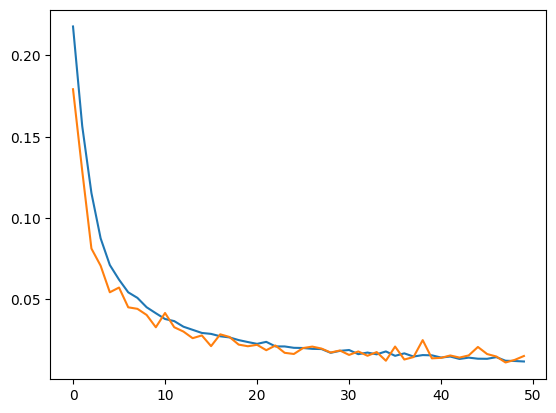

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])# Training Loss
plt.plot(history.history['val_loss'])# Validation Loss

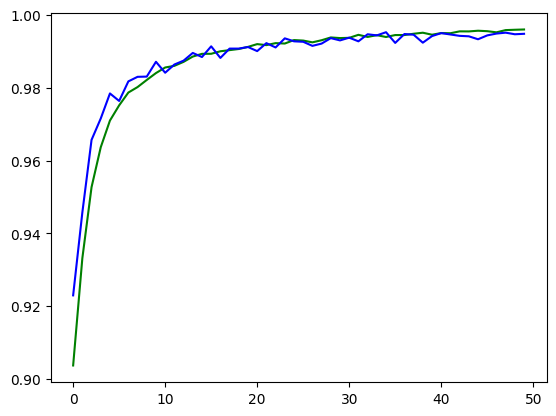

In [32]:
plt.plot(history.history['accuracy'],color='green')#Accuracy of Trained Dataset
plt.plot(history.history['val_accuracy'],color='blue')#Accuracy of Unseen Dataset

In [33]:
input_={
        "Age": 77, "RestingBP": 124, "Cholesterol": 293, "FastingBS": 0,
        "MaxHR": 114, "Oldpeak": 0.7, "Sex_F": False, "Sex_M": True,
        "ChestPainType_ASY": False, "ChestPainType_ATA": False,
        "ChestPainType_NAP": True, "ChestPainType_TA": False,
        "RestingECG_LVH": False, "RestingECG_Normal": False, "RestingECG_ST": True,
        "ExerciseAngina_N": False, "ExerciseAngina_Y": True,
        "ST_Slope_Down": False, "ST_Slope_Flat": False, "ST_Slope_Up": True
}
data_fr=pd.DataFrame([input_])
prediction=model.predict(data_fr)
if prediction==1:
 print(f"Yes! Patient has HearDisease Issues ")
else:
 print("No Patient don't have any Heart Issue Plz Be CareFull")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Yes! Patient has HearDisease Issues 


In [34]:
!pip install pyttsx3


ERROR: Could not find a version that satisfies the requirement pyttsx3 (from versions: none)
ERROR: No matching distribution found for pyttsx3
